# AutoSPECTRA — Week 5 Notebook
## Recurrence-Image Encoding and CNN Intrusion Classification

**Module:** Advanced Artificial Intelligence Projects in Data Science (55-710603)  
**Project:** AutoSPECTRA — Deep-Learning Intrusion Detection for the Connected Car  
**Group:** 7  
**Week:** 5 of 8

Week 5 introduces the **computer-vision branch** of AutoSPECTRA. The protected Week 3 split is reused unchanged. Each chronological CAN sequence is converted into a recurrence-style image and classified using a compact Convolutional Neural Network.

## Week 5 Scope

- Rebuild or load the protected Week 3 dataset.
- Reuse the fixed five-class order: Normal, DoS, Fuzzy, Gear and RPM.
- Convert each `64 × 11` CAN sequence into a `64 × 64` recurrence-style image.
- Inspect recurrence images for all five classes.
- Train the Recurrence CNN using only the training split.
- Select the best checkpoint using **validation macro-F1**.
- Evaluate the selected model once on the held-out test split.
- Save per-class precision, recall and F1.
- Save confusion matrix, ROC, precision–recall and reliability plots.
- Save training-history and model-parameter figures.
- Save confidence and error-analysis figures.
- Export a PNG-only image ZIP for GitHub evidence.
- Export a Week 5 evidence ZIP containing figures and small reports.

## Team Contributions

| Member | Name | Role | Week 5 Contribution |
|---|---|---|---|
| 1 | Amit Das | Data Interface & Split Integrity Lead | Verified reuse of the protected Week 3 source-aware chronological split, cache configuration and model-ready sequence arrays |
| 2 | Aahmad Sayeed | Recurrence CNN Lead | Implemented recurrence-image encoding, CNN architecture, training, validation, test evaluation and computer-vision result plots |
| 3 | Maheswari Kamireddy | Deep-Learning Review & Week 6 Handover Lead | Reviewed training utilities, class weighting, early stopping and the shared sequence representation needed for the Week 6 LSTM |
| 4 | Miftha Thahniyath | Artifact & Demonstration Evidence Lead | Organised saved PNG figures, CNN metadata, Kaggle image ZIP, evidence ZIP and Week 5 demonstration artifacts |
| 5 | Nagireddy Nakka | Critical Evaluation & Responsible AI Lead | Reviewed false negatives, calibration, recurrence-image information loss, dataset-specific shortcut risks and responsible interpretation |

## Eight-Week Development Plan

| Week | Technical Evidence |
|---|---|
| Week 1 | Repository setup, problem definition, architecture, roles and ethics baseline |
| Week 2 | Dataset acquisition, DLC-aware parser, source audit and initial EDA |
| Week 3 | Windowing, chronological split, leakage checks and feature representations |
| Week 4 | Logistic Regression, Random Forest, Extra Trees and XGBoost baselines |
| **Week 5** | **Recurrence-image encoder and CNN** |
| Week 6 | Bidirectional LSTM and LSTM autoencoder |
| Week 7 | Fusion, calibration, ablation, latency, error analysis and responsible AI |
| Week 8 | Incident reports, Flask application, live demonstration and final reproducibility package |

## Week 5 Boundary

Week 5 does **not** train the LSTM or LSTM autoencoder, does not perform probability fusion and does not build the Flask application.

## Kaggle Instructions and Saved Images

1. Create a Kaggle notebook.
2. Select **Add Input**.
3. Attach `pranavjha24/car-hacking-dataset`.
4. Upload this Week 5 notebook.
5. Use a GPU accelerator when available.
6. Run all cells from top to bottom.

Main output folder:

```text
/kaggle/working/autospectra_week05_outputs/
```

All figures are automatically saved to:

```text
/kaggle/working/autospectra_week05_outputs/plots/
```

At the end of the notebook download:

```text
/kaggle/working/AutoSPECTRA_Week05_Images.zip
/kaggle/working/AutoSPECTRA_Week05_Evidence.zip
```

`AutoSPECTRA_Week05_Images.zip` contains only PNG figures.  
`AutoSPECTRA_Week05_Evidence.zip` contains figures plus CSV/JSON reports, but excludes the trained `.pt` model file.

In [18]:
# 1. Imports, reproducibility and environment

import os
import gc
import json
import math
import time
import random
import hashlib
import platform
import warnings
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Week 5 Configuration

Week 5 retains the authoritative data configuration:

```text
Window size = 64 frames
Stride = 64 frames
Split strategy = source_class_chronological_v3
Classes = Normal, DoS, Fuzzy, Gear, RPM
CNN recurrence gamma = 8.0
Batch size = 256
Classifier epochs = 8
Early-stopping patience = 3
```

Only the Recurrence CNN is trained in this notebook.

In [19]:
# 2. Experiment configuration


FAST_MODE = True

WINDOW_SIZE = 64
STRIDE = 64                 # Non-overlapping windows: prevents frame leakage.
CHUNK_SIZE = 400_000
TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15
TEST_FRACTION = 0.15
MIN_ATTACK_FRAMES = 1

# Versioned strategy name is included in the cache hash. Therefore this
# corrected notebook cannot accidentally load the old normal-only test cache.
SPLIT_STRATEGY = "source_class_chronological_v3"
REBUILD_CACHE = False

if FAST_MODE:
    MAX_WINDOWS_PER_CLASS = {
        "train": 3_500,
        "validation": 800,
        "test": 800,
    }
    CLASSIFIER_EPOCHS = 8
    AUTOENCODER_EPOCHS = 8
    BATCH_SIZE = 256
    RF_TREES = 220
    ET_TREES = 220
    XGB_TREES = 260
else:
    MAX_WINDOWS_PER_CLASS = {
        "train": 12_000,
        "validation": 2_500,
        "test": 2_500,
    }
    CLASSIFIER_EPOCHS = 15
    AUTOENCODER_EPOCHS = 12
    BATCH_SIZE = 256
    RF_TREES = 400
    ET_TREES = 400
    XGB_TREES = 500

# Each source/class reservoir must be large enough to supply all three
# chronological partitions before the final per-class balancing step.
GROUP_RESERVOIR_CAPACITY = (
    sum(MAX_WINDOWS_PER_CLASS.values()) + 256
)

LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3
RUN_XGBOOST = False
RUN_DEEP_LEARNING = True
RUN_AUTOENCODER = False
RUN_FEATURE_ABLATION = False
RUN_EXPENSIVE_WINDOW_ABLATION = False

OUTPUT_DIR = Path("/kaggle/working/autospectra_week05_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in (PLOT_DIR, MODEL_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {index: name for name, index in CLASS_TO_INDEX.items()}

SOURCE_FILES = {
    "DoS": "DoS_dataset.csv",
    "Fuzzy": "Fuzzy_dataset.csv",
    "Gear": "gear_dataset.csv",
    "RPM": "RPM_dataset.csv",
}

FEATURE_NAMES = [
    "duration_s",
    "message_rate_hz",
    "iat_mean_ms",
    "iat_std_ms",
    "iat_p95_ms",
    "iat_max_ms",
    "unique_id_count",
    "id_entropy",
    "max_id_ratio",
    "id_transition_rate",
    "can_id_mean_norm",
    "can_id_std_norm",
    "dominant_id_norm",
    "zero_id_ratio",
    "dlc_mean",
    "dlc_std",
    "payload_mean",
    "payload_std",
    "payload_entropy",
    "nonzero_byte_ratio",
    "byte_change_mean",
    "byte_change_std",
    "payload_sum_mean",
    "payload_sum_std",
]

CONFIG_FOR_CACHE = {
    "split_strategy": SPLIT_STRATEGY,
    "fast_mode": FAST_MODE,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "max_windows": MAX_WINDOWS_PER_CLASS,
    "group_reservoir_capacity": GROUP_RESERVOIR_CAPACITY,
    "min_attack_frames": MIN_ATTACK_FRAMES,
}
CONFIG_HASH = hashlib.md5(
    json.dumps(CONFIG_FOR_CACHE, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

CACHE_FILE = OUTPUT_DIR / f"window_cache_{CONFIG_HASH}.npz"
CACHE_META_FILE = OUTPUT_DIR / f"window_metadata_{CONFIG_HASH}.csv"

print(json.dumps(CONFIG_FOR_CACHE, indent=2))
print("Corrected cache:", CACHE_FILE)

{
  "split_strategy": "source_class_chronological_v3",
  "fast_mode": true,
  "window_size": 64,
  "stride": 64,
  "max_windows": {
    "train": 3500,
    "validation": 800,
    "test": 800
  },
  "group_reservoir_capacity": 5356,
  "min_attack_frames": 1
}
Corrected cache: /kaggle/working/autospectra_week05_outputs/window_cache_a6bed9825e.npz


## 3. Locate HCRL Source Files

        Week 5 uses exactly the same source files and parsing rules as Weeks 2–4.

In [20]:

# 3. Dataset discovery


def locate_dataset_files(search_root: str = "/kaggle/input"):
    """Find the four expected HCRL Car-Hacking files anywhere below Kaggle input."""
    found = {}
    optional_normal = None

    for root, _, files in os.walk(search_root):
        lower_to_original = {filename.lower(): filename for filename in files}

        for attack_name, expected_filename in SOURCE_FILES.items():
            key = expected_filename.lower()
            if key in lower_to_original:
                found[attack_name] = Path(root) / lower_to_original[key]

        if "normal_run_data.txt" in lower_to_original:
            optional_normal = Path(root) / lower_to_original["normal_run_data.txt"]

    missing = sorted(set(SOURCE_FILES) - set(found))
    if missing:
        raise FileNotFoundError(
            "Missing required files for: "
            + ", ".join(missing)
            + ". Attach Kaggle dataset 'pranavjha24/car-hacking-dataset'."
        )

    return found, optional_normal

DATA_FILES, OPTIONAL_NORMAL_FILE = locate_dataset_files()

file_table = []
for attack_name, path in DATA_FILES.items():
    file_table.append({
        "Capture": attack_name,
        "Filename": path.name,
        "Path": str(path),
        "Size_MB": path.stat().st_size / (1024 ** 2),
    })

display(pd.DataFrame(file_table).sort_values("Capture"))
print("Optional normal file:", OPTIONAL_NORMAL_FILE)

,Capture,Filename,Path,Size_MB
0,DoS,DoS_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,181.254108
1,Fuzzy,Fuzzy_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,189.324157
2,Gear,gear_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,219.650663
3,RPM,RPM_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,228.483139


Optional normal file: /kaggle/input/datasets/pranavjha24/car-hacking-dataset/normal_run_data.txt


## 4. Reuse the Validated Parser, Window Builder and Split

        No new random split is created in Week 5. The recurrence CNN must use the same protected training, validation and test data established in Week 3.

In [21]:

# 4. Raw parsing, feature engineering, and corrected split builder


RAW_COLUMNS = ["Timestamp", "CAN_ID", "DLC"] + [f"X{i}" for i in range(9)]

# Hash-map conversion is faster than repeatedly calling int(text, 16)
# for millions of payload values.
HEX_BYTE_MAP = {}
for value in range(256):
    for key in {
        f"{value:02x}", f"{value:02X}",
        f"{value:x}", f"{value:X}",
    }:
        HEX_BYTE_MAP[key] = value

CAN_ID_MAP = {}
for value in range(0x800):
    for key in {
        f"{value:04x}", f"{value:04X}",
        f"{value:03x}", f"{value:03X}",
        f"{value:x}", f"{value:X}",
    }:
        CAN_ID_MAP[key] = value


def fast_line_count(path: Path) -> int:
    """Count rows with buffered binary reads."""
    with path.open("rb") as handle:
        return sum(1 for _ in handle)


def shannon_entropy(values: np.ndarray) -> float:
    """Shannon entropy in bits for a one-dimensional integer array."""
    _, counts = np.unique(values, return_counts=True)
    probabilities = counts / max(counts.sum(), 1)
    return float(
        -(probabilities * np.log2(probabilities + 1e-12)).sum()
    )


def convert_chunk(chunk: pd.DataFrame):
    """
    Convert one flexible-width HCRL raw chunk into compact NumPy arrays.

    The attack flag is not in a fixed column: it occurs immediately after
    the number of bytes specified by DLC. Missing payload positions remain 0.
    """
    chunk = chunk.dropna(
        subset=["Timestamp", "CAN_ID", "DLC"]
    ).copy()

    timestamps = pd.to_numeric(
        chunk["Timestamp"], errors="coerce"
    ).to_numpy(np.float64)

    dlc = (
        pd.to_numeric(chunk["DLC"], errors="coerce")
        .fillna(0)
        .clip(0, 8)
        .to_numpy(np.uint8)
    )

    can_text = chunk["CAN_ID"].astype(str).str.strip()
    can_ids_series = can_text.map(CAN_ID_MAP)

    missing_ids = can_ids_series.isna()
    if missing_ids.any():
        can_ids_series.loc[missing_ids] = (
            can_text.loc[missing_ids]
            .apply(lambda value: int(value, 16))
        )

    can_ids = (
        can_ids_series
        .fillna(0)
        .clip(0, 0x7FF)
        .to_numpy(np.uint16)
    )

    payload = np.zeros(
        (len(chunk), 8),
        dtype=np.uint8,
    )

    for byte_index in range(8):
        text = (
            chunk[f"X{byte_index}"]
            .astype(str)
            .str.strip()
        )
        numeric = (
            text.map(HEX_BYTE_MAP)
            .fillna(0)
            .clip(0, 255)
            .to_numpy(np.uint16)
        )
        valid = dlc > byte_index
        payload[valid, byte_index] = (
            numeric[valid].astype(np.uint8)
        )

    is_attack = np.zeros(
        len(chunk),
        dtype=bool,
    )

    for dlc_value in range(9):
        mask = dlc == dlc_value
        if not mask.any():
            continue

        flag_text = (
            chunk[f"X{dlc_value}"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        is_attack[mask] = (
            flag_text[mask]
            .eq("T")
            .to_numpy()
        )

    valid_timestamp = np.isfinite(timestamps)

    return (
        timestamps[valid_timestamp],
        can_ids[valid_timestamp],
        dlc[valid_timestamp],
        payload[valid_timestamp],
        is_attack[valid_timestamp],
    )


def build_sequence(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """
    Create the 64 x 11 sequence used by the CNN and LSTM.

    Channels:
      0    CAN ID / 2047
      1    DLC / 8
      2-9  payload bytes / 255
      10   log-scaled inter-arrival time
    """
    deltas = np.diff(
        timestamps,
        prepend=timestamps[0],
    )
    deltas = np.clip(deltas, 0, None)

    sequence = np.zeros(
        (len(timestamps), 11),
        dtype=np.float32,
    )

    sequence[:, 0] = np.clip(
        can_ids.astype(np.float32) / 2047.0,
        0,
        1,
    )
    sequence[:, 1] = (
        dlc.astype(np.float32) / 8.0
    )
    sequence[:, 2:10] = (
        payload.astype(np.float32) / 255.0
    )
    sequence[:, 10] = np.clip(
        np.log1p(deltas * 1_000_000.0) / 15.0,
        0,
        1,
    )

    return sequence.astype(np.float16)


def build_tabular_features(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """Engineer window features without flags, labels, or future values."""
    duration = max(
        float(timestamps[-1] - timestamps[0]),
        1e-9,
    )

    deltas = np.diff(timestamps)
    positive_deltas = np.clip(
        deltas,
        0,
        None,
    )
    iat_ms = positive_deltas * 1000.0

    unique_ids, id_counts = np.unique(
        can_ids,
        return_counts=True,
    )
    dominant_position = int(
        np.argmax(id_counts)
    )
    dominant_id = int(
        unique_ids[dominant_position]
    )
    max_id_ratio = float(
        id_counts[dominant_position]
        / len(can_ids)
    )

    payload_flat = payload.reshape(-1)

    if len(payload) > 1:
        payload_differences = np.abs(
            np.diff(
                payload.astype(np.float32),
                axis=0,
            )
        ).mean(axis=1)
    else:
        payload_differences = np.array(
            [0.0],
            dtype=np.float32,
        )

    payload_sums = (
        payload.sum(axis=1)
        .astype(np.float32)
    )

    return np.array([
        duration,
        len(timestamps) / duration,
        float(iat_ms.mean()) if len(iat_ms) else 0.0,
        float(iat_ms.std()) if len(iat_ms) else 0.0,
        float(np.percentile(iat_ms, 95)) if len(iat_ms) else 0.0,
        float(iat_ms.max()) if len(iat_ms) else 0.0,
        len(unique_ids),
        shannon_entropy(can_ids),
        max_id_ratio,
        (
            float(np.mean(can_ids[1:] != can_ids[:-1]))
            if len(can_ids) > 1
            else 0.0
        ),
        float(can_ids.mean() / 2047.0),
        float(can_ids.std() / 2047.0),
        dominant_id / 2047.0,
        float(np.mean(can_ids == 0)),
        float(dlc.mean()),
        float(dlc.std()),
        float(payload.mean()),
        float(payload.std()),
        shannon_entropy(payload_flat),
        float(np.mean(payload_flat != 0)),
        float(payload_differences.mean()),
        float(payload_differences.std()),
        float(payload_sums.mean()),
        float(payload_sums.std()),
    ], dtype=np.float32)


class Reservoir:
    """Deterministic fixed-capacity reservoir sampler."""

    def __init__(
        self,
        capacity: int,
        seed: int,
    ):
        self.capacity = int(capacity)
        self.rng = np.random.default_rng(seed)
        self.seen = 0
        self.items = []

    def choose_slot(self):
        self.seen += 1

        if len(self.items) < self.capacity:
            return len(self.items)

        candidate = int(
            self.rng.integers(0, self.seen)
        )

        return (
            candidate
            if candidate < self.capacity
            else None
        )

    def store(
        self,
        slot: int,
        item: dict,
    ):
        if slot == len(self.items):
            self.items.append(item)
        else:
            self.items[slot] = item


def make_reservoirs():
    """
    Keep separate reservoirs for each source capture and each label.

    This is the core correction: sampling occurs across the full capture
    before any split is assigned. Consequently, later attack windows remain
    available for validation and testing.
    """
    reservoirs = {}

    for source_index, source_attack in enumerate(SOURCE_FILES):
        reservoirs[source_attack] = {}

        for local_index, class_name in enumerate(
            ["Normal", source_attack]
        ):
            reservoirs[source_attack][class_name] = Reservoir(
                GROUP_RESERVOIR_CAPACITY,
                SEED
                + source_index * 100
                + local_index,
            )

    return reservoirs


def process_capture(
    path: Path,
    source_attack: str,
    total_rows: int,
    reservoirs: dict,
    chunk_size: int = CHUNK_SIZE,
):
    """
    Stream one full capture and create non-overlapping candidate windows.

    No train/validation/test decision is made here. Windows are first sampled
    across the entire source/class timeline and split later.
    """
    print(
        f"\nProcessing {source_attack}: "
        f"{path.name} ({total_rows:,} rows)"
    )

    carry = None
    carry_global_start = 0
    global_chunk_start = 0
    next_window_start = 0
    processed_windows = 0
    accepted_windows = 0

    reader = pd.read_csv(
        path,
        header=None,
        names=RAW_COLUMNS,
        dtype=str,
        chunksize=chunk_size,
        engine="c",
        on_bad_lines="skip",
    )

    for chunk_number, chunk in enumerate(
        reader,
        start=1,
    ):
        (
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
        ) = convert_chunk(chunk)

        current_length = len(timestamps)

        if carry is None:
            combined = (
                timestamps,
                can_ids,
                dlc,
                payload,
                flags,
            )
            combined_global_start = (
                global_chunk_start
            )
        else:
            combined = (
                np.concatenate(
                    [carry[0], timestamps]
                ),
                np.concatenate(
                    [carry[1], can_ids]
                ),
                np.concatenate(
                    [carry[2], dlc]
                ),
                np.concatenate(
                    [carry[3], payload],
                    axis=0,
                ),
                np.concatenate(
                    [carry[4], flags]
                ),
            )
            combined_global_start = (
                carry_global_start
            )

        combined_end_global = (
            combined_global_start
            + len(combined[0])
        )

        if next_window_start < combined_global_start:
            next_window_start = (
                combined_global_start
            )

        while (
            next_window_start + WINDOW_SIZE
            <= combined_end_global
        ):
            local_start = (
                next_window_start
                - combined_global_start
            )
            local_end = (
                local_start + WINDOW_SIZE
            )

            window_flags = combined[4][
                local_start:local_end
            ]
            attack_count = int(
                window_flags.sum()
            )

            if attack_count >= MIN_ATTACK_FRAMES:
                class_name = source_attack
                first_attack_position = int(
                    np.flatnonzero(
                        window_flags
                    )[0]
                )
            else:
                class_name = "Normal"
                first_attack_position = -1

            reservoir = reservoirs[
                source_attack
            ][class_name]

            selected_slot = (
                reservoir.choose_slot()
            )

            if selected_slot is not None:
                win_ts = combined[0][
                    local_start:local_end
                ]
                win_ids = combined[1][
                    local_start:local_end
                ]
                win_dlc = combined[2][
                    local_start:local_end
                ]
                win_payload = combined[3][
                    local_start:local_end
                ]

                features = build_tabular_features(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )
                sequence = build_sequence(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )

                if first_attack_position >= 0:
                    latency_upper_bound_ms = float(
                        (
                            win_ts[-1]
                            - win_ts[
                                first_attack_position
                            ]
                        )
                        * 1000.0
                    )
                else:
                    latency_upper_bound_ms = np.nan

                unique_ids, counts = np.unique(
                    win_ids,
                    return_counts=True,
                )
                dominant_id = int(
                    unique_ids[
                        np.argmax(counts)
                    ]
                )

                item = {
                    "sequence": sequence,
                    "features": features,
                    "label": CLASS_TO_INDEX[
                        class_name
                    ],
                    "metadata": {
                        "split": "unassigned",
                        "class_name": class_name,
                        "source_capture": source_attack,
                        "start_timestamp":
                            float(win_ts[0]),
                        "end_timestamp":
                            float(win_ts[-1]),
                        "global_start_row":
                            int(next_window_start),
                        "attack_frame_count":
                            attack_count,
                        "attack_ratio":
                            attack_count / WINDOW_SIZE,
                        "first_attack_position":
                            first_attack_position,
                        "latency_upper_bound_ms":
                            latency_upper_bound_ms,
                        "dominant_can_id":
                            dominant_id,
                        "dominant_can_id_hex":
                            f"0x{dominant_id:03X}",
                    },
                }

                reservoir.store(
                    selected_slot,
                    item,
                )
                accepted_windows += 1

            processed_windows += 1
            next_window_start += STRIDE

        keep = min(
            WINDOW_SIZE - 1,
            len(combined[0]),
        )

        carry = (
            combined[0][-keep:].copy(),
            combined[1][-keep:].copy(),
            combined[2][-keep:].copy(),
            combined[3][-keep:].copy(),
            combined[4][-keep:].copy(),
        )
        carry_global_start = (
            combined_end_global - keep
        )
        global_chunk_start += current_length

        if chunk_number % 5 == 0:
            print(
                f"  chunk {chunk_number:>2} | "
                f"rows read {global_chunk_start:,} | "
                f"candidate windows "
                f"{processed_windows:,} | "
                f"reservoir writes "
                f"{accepted_windows:,}"
            )

        del (
            chunk,
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
            combined,
        )
        gc.collect()

    print(
        f"Finished {source_attack}: "
        f"{processed_windows:,} candidate windows, "
        f"{accepted_windows:,} reservoir writes."
    )


def chronological_partition(
    items,
):
    """
    Divide one source/class group chronologically.

    Because windows are non-overlapping, boundaries do not share CAN frames.
    At least one item is retained in every split when the group has >= 3.
    """
    items = sorted(
        items,
        key=lambda item:
            item["metadata"]["global_start_row"],
    )

    number_of_items = len(items)

    if number_of_items < 3:
        raise RuntimeError(
            "A source/class group has fewer than three sampled "
            f"windows ({number_of_items}); cannot form all splits."
        )

    train_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * TRAIN_FRACTION
            )
        ),
    )

    validation_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * VALID_FRACTION
            )
        ),
    )

    # Reserve at least one item for test.
    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        validation_count = max(
            1,
            number_of_items
            - train_count
            - 1,
        )

    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        train_count = max(
            1,
            number_of_items
            - validation_count
            - 1,
        )

    train_end = train_count
    validation_end = (
        train_count + validation_count
    )

    partitions = {
        "train": items[:train_end],
        "validation":
            items[train_end:validation_end],
        "test":
            items[validation_end:],
    }

    if any(
        len(partition) == 0
        for partition in partitions.values()
    ):
        raise RuntimeError(
            "Chronological partition created an empty split."
        )

    return partitions


def deterministic_cap(
    items,
    capacity,
    seed,
):
    """Select a reproducible subset while retaining broad time coverage."""
    if len(items) <= capacity:
        return list(items)

    ordered = sorted(
        items,
        key=lambda item: (
            item["metadata"]["source_capture"],
            item["metadata"]["global_start_row"],
        ),
    )

    # Evenly spaced selection gives coverage across the complete period
    # instead of concentrating on one short interval.
    positions = np.linspace(
        0,
        len(ordered) - 1,
        num=capacity,
        dtype=int,
    )

    return [
        ordered[position]
        for position in positions
    ]


def finalise_reservoirs(
    reservoirs,
):
    """
    Build balanced train/validation/test arrays with every class present.

    Splitting is chronological inside each source/class group. Final caps are
    applied only after these partitions have been formed.
    """
    grouped_split_items = {
        split_name: {
            class_name: []
            for class_name in CLASS_NAMES
        }
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    group_summary = []

    for source_attack in SOURCE_FILES:
        for class_name in [
            "Normal",
            source_attack,
        ]:
            group_items = reservoirs[
                source_attack
            ][class_name].items

            partitions = chronological_partition(
                group_items
            )

            group_summary.append({
                "Source_Capture":
                    source_attack,
                "Class":
                    class_name,
                "Sampled_Total":
                    len(group_items),
                "Train":
                    len(partitions["train"]),
                "Validation":
                    len(partitions["validation"]),
                "Test":
                    len(partitions["test"]),
            })

            for (
                split_name,
                split_items,
            ) in partitions.items():
                for item in split_items:
                    item["metadata"][
                        "split"
                    ] = split_name

                grouped_split_items[
                    split_name
                ][class_name].extend(
                    split_items
                )

    group_summary_df = pd.DataFrame(
        group_summary
    )
    print(
        "\nSource/class chronological "
        "partition summary:"
    )
    display(group_summary_df)

    output = {}

    for split_index, split_name in enumerate(
        ["train", "validation", "test"]
    ):
        selected_items = []

        for class_index, class_name in enumerate(
            CLASS_NAMES
        ):
            class_items = grouped_split_items[
                split_name
            ][class_name]

            if not class_items:
                raise RuntimeError(
                    f"No {class_name} windows were available "
                    f"for split '{split_name}'."
                )

            class_items = deterministic_cap(
                class_items,
                MAX_WINDOWS_PER_CLASS[
                    split_name
                ],
                SEED
                + split_index * 100
                + class_index,
            )

            selected_items.extend(
                class_items
            )

        rng = np.random.default_rng(
            SEED + split_index
        )
        rng.shuffle(selected_items)

        sequences = np.stack([
            item["sequence"]
            for item in selected_items
        ]).astype(np.float16)

        features = np.stack([
            item["features"]
            for item in selected_items
        ]).astype(np.float32)

        labels = np.array([
            item["label"]
            for item in selected_items
        ], dtype=np.int64)

        metadata = pd.DataFrame([
            item["metadata"]
            for item in selected_items
        ])

        output[split_name] = {
            "sequences": sequences,
            "features": features,
            "labels": labels,
            "metadata": metadata,
        }

    return output


## 5. Build or Load the Versioned Cache

In [22]:

# 5. Build/load cache


def save_window_cache(data):
    np.savez_compressed(
        CACHE_FILE,
        train_sequences=data["train"]["sequences"],
        train_features=data["train"]["features"],
        train_labels=data["train"]["labels"],
        validation_sequences=data["validation"]["sequences"],
        validation_features=data["validation"]["features"],
        validation_labels=data["validation"]["labels"],
        test_sequences=data["test"]["sequences"],
        test_features=data["test"]["features"],
        test_labels=data["test"]["labels"],
    )

    metadata_frames = []

    for split_name in ["train", "validation", "test"]:
        frame = data[split_name]["metadata"].copy()
        frame["cache_split"] = split_name
        frame["cache_row"] = np.arange(len(frame))
        metadata_frames.append(frame)

    pd.concat(
        metadata_frames, ignore_index=True
    ).to_csv(CACHE_META_FILE, index=False)

    with (
        OUTPUT_DIR / f"config_{CONFIG_HASH}.json"
    ).open("w") as handle:
        json.dump(CONFIG_FOR_CACHE, handle, indent=2)


def load_window_cache():
    arrays = np.load(CACHE_FILE, allow_pickle=False)
    metadata = pd.read_csv(CACHE_META_FILE)

    data = {}

    for split_name in ["train", "validation", "test"]:
        split_metadata = (
            metadata[
                metadata["cache_split"] == split_name
            ]
            .sort_values("cache_row")
            .reset_index(drop=True)
        )

        data[split_name] = {
            "sequences":
                arrays[f"{split_name}_sequences"],
            "features":
                arrays[f"{split_name}_features"],
            "labels":
                arrays[f"{split_name}_labels"],
            "metadata": split_metadata,
        }

    return data


if (
    CACHE_FILE.exists()
    and CACHE_META_FILE.exists()
    and not REBUILD_CACHE
):
    print("Loading corrected source/class chronological cache...")
    DATA = load_window_cache()
else:
    print("Counting rows before corrected source/class chronological extraction...")

    ROW_COUNTS = {
        attack_name: fast_line_count(path)
        for attack_name, path in DATA_FILES.items()
    }

    display(pd.DataFrame([
        {"Capture": name, "Rows": count}
        for name, count in ROW_COUNTS.items()
    ]))

    reservoirs = make_reservoirs()

    for source_attack, path in DATA_FILES.items():
        process_capture(
            path=path,
            source_attack=source_attack,
            total_rows=ROW_COUNTS[source_attack],
            reservoirs=reservoirs,
        )

    DATA = finalise_reservoirs(reservoirs)
    save_window_cache(DATA)


for split_name, split_data in DATA.items():
    print(
        split_name,
        "| sequences:", split_data["sequences"].shape,
        "| features:", split_data["features"].shape,
        "| labels:", split_data["labels"].shape,
    )

Counting rows before corrected source/class chronological extraction...


,Capture,Rows
0,DoS,3665771
1,Fuzzy,3838860
2,Gear,4443142
3,RPM,4621702



Processing DoS: DoS_dataset.csv (3,665,771 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,039
  chunk 10 | rows read 3,665,771 | candidate windows 57,277 | reservoir writes 27,748
Finished DoS: 57,277 candidate windows, 27,748 reservoir writes.

Processing Fuzzy: Fuzzy_dataset.csv (3,838,860 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,176
  chunk 10 | rows read 3,838,860 | candidate windows 59,982 | reservoir writes 28,614
Finished Fuzzy: 59,982 candidate windows, 28,614 reservoir writes.

Processing Gear: gear_dataset.csv (4,443,142 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,252
  chunk 10 | rows read 4,000,000 | candidate windows 62,500 | reservoir writes 29,695
Finished Gear: 69,424 candidate windows, 30,746 reservoir writes.

Processing RPM: RPM_dataset.csv (4,621,702 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 2

,Source_Capture,Class,Sampled_Total,Train,Validation,Test
0,DoS,Normal,5356,3749,803,804
1,DoS,DoS,5356,3749,803,804
2,Fuzzy,Normal,5356,3749,803,804
3,Fuzzy,Fuzzy,5356,3749,803,804
4,Gear,Normal,5356,3749,803,804
5,Gear,Gear,5356,3749,803,804
6,RPM,Normal,5356,3749,803,804
7,RPM,RPM,5356,3749,803,804


train | sequences: (17500, 64, 11) | features: (17500, 24) | labels: (17500,)
validation | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)
test | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)


In [23]:
# Validate class coverage and confirm that labels are never features.
summary_rows = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    counts = (
        pd.Series(
            DATA[split_name]["labels"]
        )
        .value_counts()
        .sort_index()
    )

    for (
        class_index,
        class_name,
    ) in enumerate(CLASS_NAMES):
        summary_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Windows": int(
                counts.get(
                    class_index,
                    0,
                )
            ),
        })

split_class_counts = pd.DataFrame(
    summary_rows
)

coverage_table = (
    split_class_counts
    .pivot(
        index="Class",
        columns="Split",
        values="Windows",
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

display(coverage_table)

missing_pairs = [
    f"{class_name} in {split_name}"
    for class_name in CLASS_NAMES
    for split_name in [
        "train",
        "validation",
        "test",
    ]
    if coverage_table.loc[
        class_name,
        split_name,
    ] == 0
]

if missing_pairs:
    raise RuntimeError(
        "Invalid class coverage: "
        + ", ".join(missing_pairs)
        + ". Delete old caches or set REBUILD_CACHE=True, "
        "then rerun from the configuration cell."
    )

expected_class_indices = set(
    range(len(CLASS_NAMES))
)

for split_name in [
    "train",
    "validation",
    "test",
]:
    observed = set(
        np.unique(
            DATA[split_name]["labels"]
        )
    )

    if observed != expected_class_indices:
        raise RuntimeError(
            f"Split '{split_name}' contains labels "
            f"{sorted(observed)}, expected "
            f"{sorted(expected_class_indices)}."
        )

assert (
    DATA["train"]["features"].shape[1]
    == len(FEATURE_NAMES)
)

assert not any(
    "label" in name.lower()
    or "flag" in name.lower()
    or "attack_frame" in name.lower()
    for name in FEATURE_NAMES
)

assert STRIDE >= WINDOW_SIZE, (
    "Use non-overlapping windows to avoid shared-frame leakage."
)

print(
    "Coverage audit passed: all five classes occur in "
    "train, validation, and unseen test sets."
)
print(
    "Feature audit passed: no target or attack-flag feature "
    "is used by any model."
)


Split,test,train,validation
Class,,,
Normal,800,3500,800
DoS,800,3500,800
Fuzzy,800,3500,800
Gear,800,3500,800
RPM,800,3500,800


Coverage audit passed: all five classes occur in train, validation, and unseen test sets.
Feature audit passed: no target or attack-flag feature is used by any model.


In [24]:
# 6. Prepare Week 5 arrays

y_train = DATA["train"]["labels"]
y_validation = DATA["validation"]["labels"]
y_test = DATA["test"]["labels"]

X_train_seq = DATA["train"]["sequences"]
X_validation_seq = DATA["validation"]["sequences"]
X_test_seq = DATA["test"]["sequences"]

print(
    "Train sequences:",
    X_train_seq.shape,
)
print(
    "Validation sequences:",
    X_validation_seq.shape,
)
print(
    "Test sequences:",
    X_test_seq.shape,
)

assert X_train_seq.shape[1:] == (
    WINDOW_SIZE,
    11,
)
assert X_validation_seq.shape[1:] == (
    WINDOW_SIZE,
    11,
)
assert X_test_seq.shape[1:] == (
    WINDOW_SIZE,
    11,
)

Train sequences: (17500, 64, 11)
Validation sequences: (4000, 64, 11)
Test sequences: (4000, 64, 11)


In [25]:
# 7. Figure helper

def save_current_figure(filename: str):
    path = PLOT_DIR / filename
    plt.tight_layout()
    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()
    print("Saved image:", path)

# Part A — Recurrence-Image Encoding

In [26]:
# 8. Convert one CAN sequence to a recurrence-style image

RECURRENCE_GAMMA = 8.0

def sequence_signal(
    sequence: np.ndarray,
) -> np.ndarray:
    sequence = sequence.astype(
        np.float32
    )

    return (
        0.35 * sequence[:, 0]
        + 0.10 * sequence[:, 1]
        + 0.45
        * sequence[:, 2:10].mean(
            axis=1
        )
        + 0.10 * sequence[:, 10]
    )

def sequence_to_recurrence(
    sequence: np.ndarray,
    gamma: float = RECURRENCE_GAMMA,
) -> np.ndarray:
    signal = sequence_signal(sequence)

    distance = np.abs(
        signal[:, None]
        - signal[None, :]
    )

    image = np.exp(
        -gamma * distance
    ).astype(np.float32)

    assert image.shape == (
        WINDOW_SIZE,
        WINDOW_SIZE,
    )
    assert np.isfinite(image).all()
    assert image.min() >= 0
    assert image.max() <= 1

    return image

example_image = sequence_to_recurrence(
    X_train_seq[0]
)

print(
    "Recurrence image shape:",
    example_image.shape,
)
print(
    "Range:",
    float(example_image.min()),
    "to",
    float(example_image.max()),
)

Recurrence image shape: (64, 64)
Range: 0.008407507091760635 to 1.0


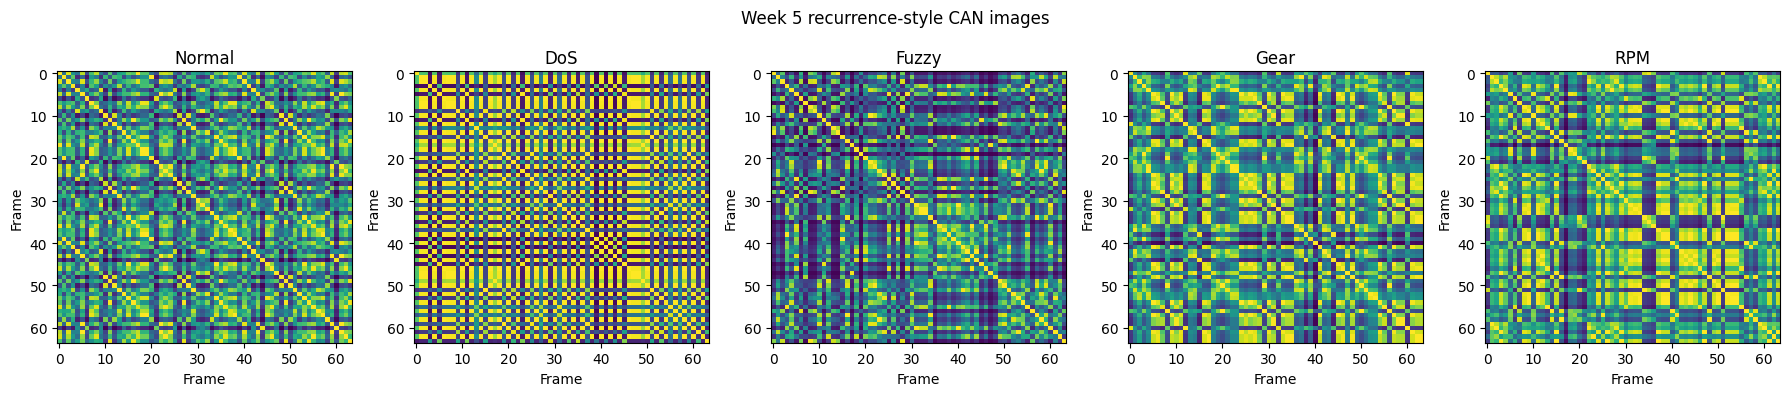

,Class,Example_Index,Image_Min,Image_Max,Image_Mean,Image_Std
0,Normal,3,0.055175,1.0,0.536148,0.256689
1,DoS,1,0.043789,1.0,0.530326,0.362173
2,Fuzzy,0,0.008408,1.0,0.394540,0.279183
3,Gear,8,0.075000,1.0,0.571171,0.268348
4,RPM,5,0.065873,1.0,0.571235,0.272413


In [27]:
# 9. Save one recurrence image for every traffic class

recurrence_rows = []

fig, axes = plt.subplots(
    1,
    len(CLASS_NAMES),
    figsize=(18, 4),
)

for (
    class_index,
    class_name,
) in enumerate(CLASS_NAMES):

    example_index = int(
        np.flatnonzero(
            y_train == class_index
        )[0]
    )

    sequence = X_train_seq[
        example_index
    ]

    image = sequence_to_recurrence(
        sequence
    )

    axes[class_index].imshow(
        image,
        aspect="auto",
    )

    axes[class_index].set_title(
        class_name
    )
    axes[class_index].set_xlabel(
        "Frame"
    )
    axes[class_index].set_ylabel(
        "Frame"
    )

    recurrence_rows.append({
        "Class": class_name,
        "Example_Index":
            example_index,
        "Image_Min":
            float(image.min()),
        "Image_Max":
            float(image.max()),
        "Image_Mean":
            float(image.mean()),
        "Image_Std":
            float(image.std()),
    })

fig.suptitle(
    "Week 5 recurrence-style CAN images"
)

plt.tight_layout()

path = (
    PLOT_DIR
    / "week05_recurrence_examples.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

recurrence_audit_df = pd.DataFrame(
    recurrence_rows
)

display(recurrence_audit_df)

recurrence_audit_df.to_csv(
    REPORT_DIR
    / "week05_recurrence_audit.csv",
    index=False,
)

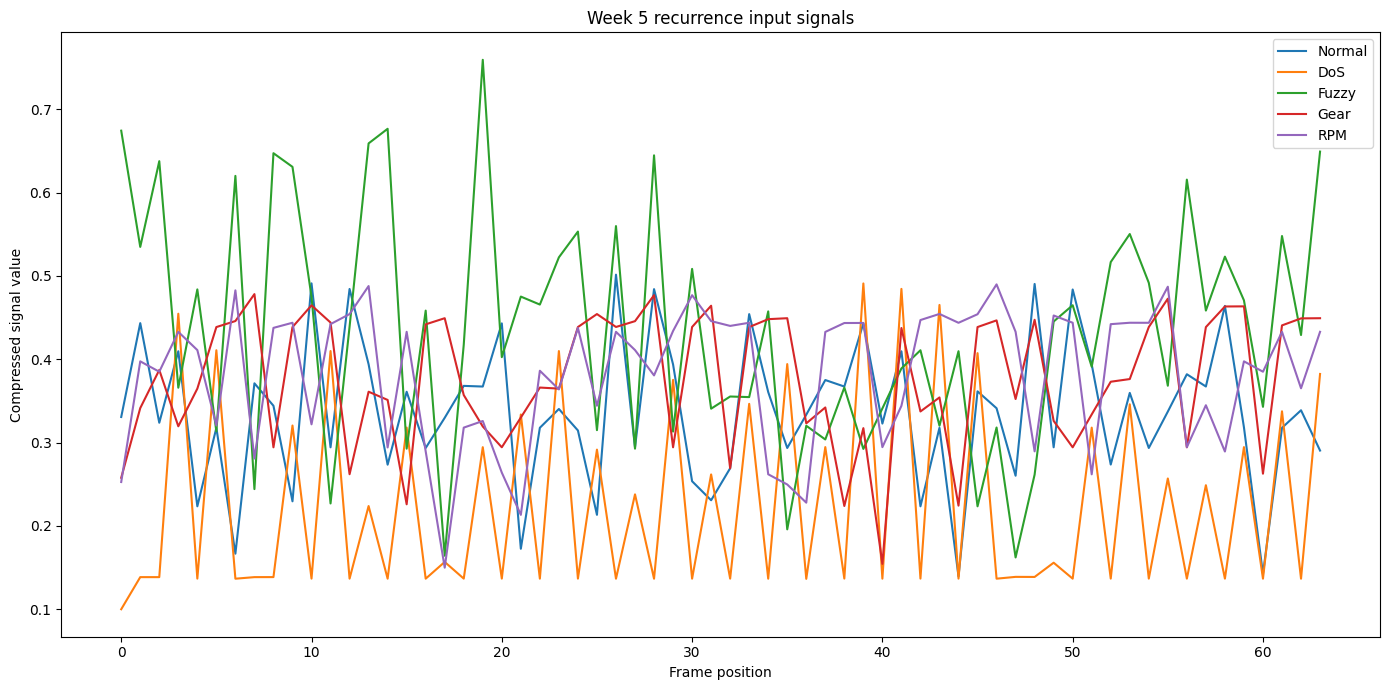

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_recurrence_signals.png


In [28]:
# 10. Save the compact signals used to construct recurrence images

plt.figure(
    figsize=(14, 7)
)

for (
    class_index,
    class_name,
) in enumerate(CLASS_NAMES):

    example_index = int(
        np.flatnonzero(
            y_train == class_index
        )[0]
    )

    signal = sequence_signal(
        X_train_seq[example_index]
    )

    plt.plot(
        np.arange(WINDOW_SIZE),
        signal,
        label=class_name,
    )

plt.title(
    "Week 5 recurrence input signals"
)
plt.xlabel("Frame position")
plt.ylabel("Compressed signal value")
plt.legend()

save_current_figure(
    "week05_recurrence_signals.png"
)

,Class,Sampled_Images,Mean_Similarity,Mean_Image_Std
0,Normal,150,0.534914,0.254281
1,DoS,150,0.517841,0.347258
2,Fuzzy,150,0.418758,0.282058
3,Gear,150,0.559251,0.274062
4,RPM,150,0.558698,0.266721


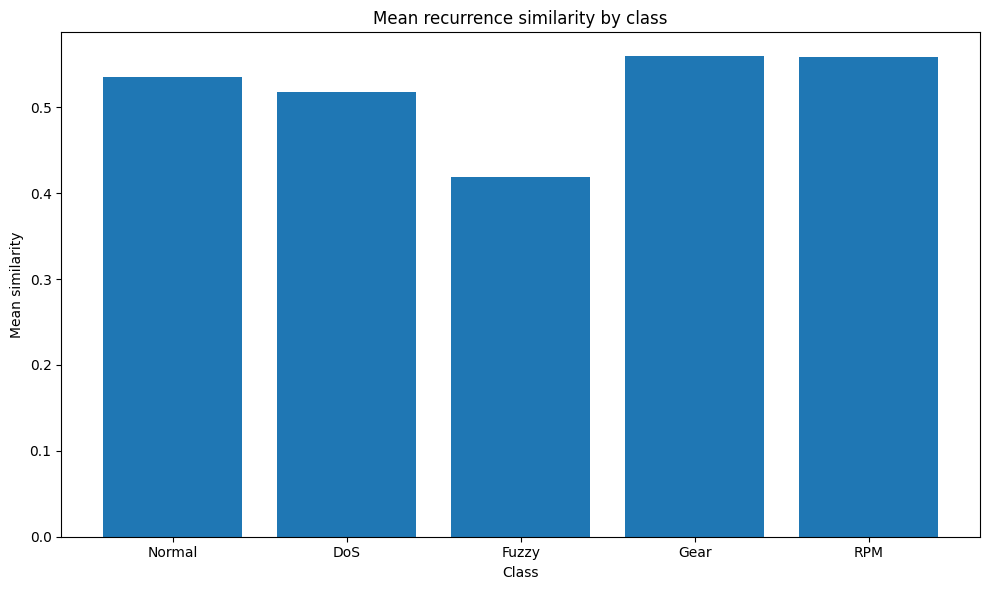

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_recurrence_similarity_by_class.png


In [29]:
# 11. Sample recurrence-image statistics by class

recurrence_statistics = []

rng = np.random.default_rng(SEED)

for (
    class_index,
    class_name,
) in enumerate(CLASS_NAMES):

    indices = np.flatnonzero(
        y_train == class_index
    )

    sample_size = min(
        150,
        len(indices),
    )

    selected = rng.choice(
        indices,
        size=sample_size,
        replace=False,
    )

    image_means = []
    image_stds = []

    for index in selected:
        image = sequence_to_recurrence(
            X_train_seq[index]
        )

        image_means.append(
            image.mean()
        )
        image_stds.append(
            image.std()
        )

    recurrence_statistics.append({
        "Class": class_name,
        "Sampled_Images":
            sample_size,
        "Mean_Similarity":
            float(
                np.mean(
                    image_means
                )
            ),
        "Mean_Image_Std":
            float(
                np.mean(
                    image_stds
                )
            ),
    })

recurrence_statistics_df = (
    pd.DataFrame(
        recurrence_statistics
    )
)

display(
    recurrence_statistics_df
)

recurrence_statistics_df.to_csv(
    REPORT_DIR
    / "week05_recurrence_statistics.csv",
    index=False,
)

plt.figure(figsize=(10, 6))

plt.bar(
    recurrence_statistics_df[
        "Class"
    ],
    recurrence_statistics_df[
        "Mean_Similarity"
    ],
)

plt.title(
    "Mean recurrence similarity by class"
)
plt.xlabel("Class")
plt.ylabel("Mean similarity")

save_current_figure(
    "week05_recurrence_similarity_by_class.png"
)

# Part B — Recurrence CNN Architecture

In [30]:
# 12. Dataset, loader and CNN definition

class CANRecurrenceDataset(
    Dataset
):
    def __init__(
        self,
        sequences,
        labels,
        gamma=RECURRENCE_GAMMA,
    ):
        self.sequences = sequences
        self.labels = labels
        self.gamma = gamma

    def __len__(self):
        return len(self.labels)

    def __getitem__(
        self,
        index,
    ):
        sequence = torch.from_numpy(
            self.sequences[
                index
            ].astype(np.float32)
        )

        signal = (
            0.35
            * sequence[:, 0]
            + 0.10
            * sequence[:, 1]
            + 0.45
            * sequence[
                :, 2:10
            ].mean(dim=1)
            + 0.10
            * sequence[:, 10]
        )

        distance = torch.abs(
            signal[:, None]
            - signal[None, :]
        )

        image = torch.exp(
            -self.gamma
            * distance
        ).unsqueeze(0)

        label = torch.tensor(
            int(
                self.labels[index]
            ),
            dtype=torch.long,
        )

        return image, label


class RecurrenceCNN(
    nn.Module
):
    def __init__(
        self,
        number_of_classes=
            len(CLASS_NAMES),
    ):
        super().__init__()

        self.features = (
            nn.Sequential(
                nn.Conv2d(
                    1,
                    16,
                    kernel_size=3,
                    padding=1,
                ),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(2),

                nn.Conv2d(
                    16,
                    32,
                    kernel_size=3,
                    padding=1,
                ),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2),

                nn.Conv2d(
                    32,
                    64,
                    kernel_size=3,
                    padding=1,
                ),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d(
                    (1, 1)
                ),
            )
        )

        self.classifier = (
            nn.Sequential(
                nn.Flatten(),
                nn.Dropout(0.25),
                nn.Linear(
                    64,
                    number_of_classes,
                ),
            )
        )

    def forward(
        self,
        inputs,
    ):
        return self.classifier(
            self.features(
                inputs
            )
        )


def create_loader(
    dataset,
    shuffle=False,
):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=
            torch.cuda.is_available(),
        drop_last=False,
    )


cnn = RecurrenceCNN()

total_parameters = sum(
    parameter.numel()
    for parameter
    in cnn.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in cnn.parameters()
    if parameter.requires_grad
)

print(cnn)
print(
    "Total parameters:",
    f"{total_parameters:,}",
)
print(
    "Trainable parameters:",
    f"{trainable_parameters:,}",
)

RecurrenceCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)
Total parameters: 23,845

,Parameter,Count,Trainable
0,features.0.weight,144,True
1,features.0.bias,16,True
2,features.1.weight,16,True
3,features.1.bias,16,True
4,features.4.weight,4608,True
5,features.4.bias,32,True
6,features.5.weight,32,True
7,features.5.bias,32,True
8,features.8.weight,18432,True
9,features.8.bias,64,True


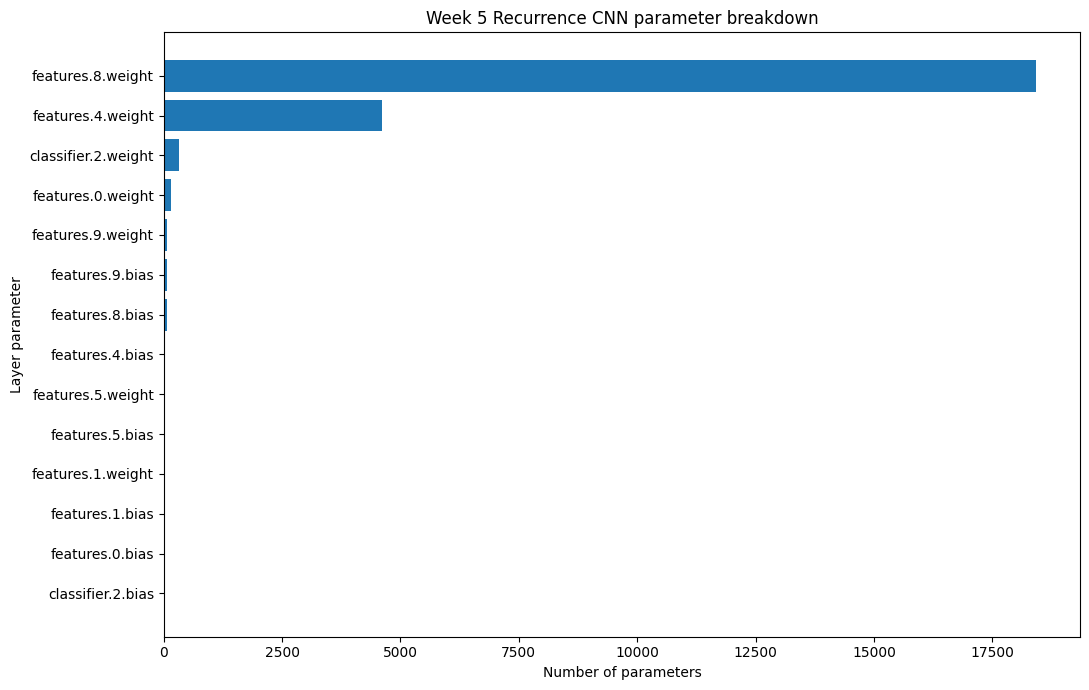

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_parameter_breakdown.png


In [31]:
# 13. Save CNN parameter breakdown

parameter_rows = []

for name, parameter in (
    cnn.named_parameters()
):
    parameter_rows.append({
        "Parameter": name,
        "Count":
            int(
                parameter.numel()
            ),
        "Trainable":
            bool(
                parameter.requires_grad
            ),
    })

parameter_df = pd.DataFrame(
    parameter_rows
)

display(parameter_df)

parameter_df.to_csv(
    REPORT_DIR
    / "week05_cnn_parameter_breakdown.csv",
    index=False,
)

plot_df = (
    parameter_df
    .sort_values(
        "Count",
        ascending=True,
    )
)

plt.figure(
    figsize=(11, 7)
)

plt.barh(
    plot_df["Parameter"],
    plot_df["Count"],
)

plt.xlabel(
    "Number of parameters"
)
plt.ylabel(
    "Layer parameter"
)
plt.title(
    "Week 5 Recurrence CNN parameter breakdown"
)

save_current_figure(
    "week05_cnn_parameter_breakdown.png"
)

# Part C — CNN Training with Validation-Based Early Stopping

In [32]:
# 14. Training and prediction utilities

def probabilities_from_cnn(
    model,
    loader,
):
    model.eval()

    probability_batches = []
    label_batches = []

    with torch.no_grad():
        for (
            inputs,
            labels,
        ) in loader:

            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(
                inputs
            )

            probabilities = (
                torch.softmax(
                    logits,
                    dim=1,
                )
            )

            probability_batches.append(
                probabilities
                .cpu()
                .numpy()
            )

            label_batches.append(
                labels.numpy()
            )

    return (
        np.concatenate(
            probability_batches
        ),
        np.concatenate(
            label_batches
        ),
    )


def train_recurrence_cnn(
    model,
    train_loader,
    validation_loader,
):
    class_values = np.unique(
        y_train
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=class_values,
        y=y_train,
    )

    full_weights = np.ones(
        len(CLASS_NAMES),
        dtype=np.float32,
    )

    full_weights[
        class_values
    ] = weights.astype(
        np.float32
    )

    criterion = (
        nn.CrossEntropyLoss(
            weight=torch.tensor(
                full_weights,
                device=DEVICE,
            ),
            label_smoothing=0.02,
        )
    )

    optimizer = (
        torch.optim.AdamW(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=1e-4,
        )
    )

    model = model.to(DEVICE)

    best_state = None
    best_macro_f1 = -np.inf
    best_epoch = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(
        1,
        CLASSIFIER_EPOCHS + 1,
    ):
        model.train()

        running_loss = 0.0
        seen = 0

        for (
            inputs,
            labels,
        ) in train_loader:

            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                inputs
            )

            loss = criterion(
                logits,
                labels,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=2.0,
            )

            optimizer.step()

            running_loss += (
                loss.item()
                * len(labels)
            )

            seen += len(labels)

        (
            validation_probabilities,
            validation_labels,
        ) = probabilities_from_cnn(
            model,
            validation_loader,
        )

        validation_predictions = (
            validation_probabilities
            .argmax(axis=1)
        )

        validation_macro_f1 = (
            f1_score(
                validation_labels,
                validation_predictions,
                average="macro",
                zero_division=0,
            )
        )

        epoch_loss = (
            running_loss
            / max(seen, 1)
        )

        history.append({
            "Epoch": epoch,
            "Training_Loss":
                epoch_loss,
            "Validation_Macro_F1":
                validation_macro_f1,
        })

        print(
            f"Epoch {epoch:02d} | "
            f"loss {epoch_loss:.4f} | "
            f"validation macro-F1 "
            f"{validation_macro_f1:.4f}"
        )

        if (
            validation_macro_f1
            > best_macro_f1
            + 1e-4
        ):
            best_macro_f1 = (
                validation_macro_f1
            )

            best_epoch = epoch

            best_state = {
                key:
                    value
                    .detach()
                    .cpu()
                    .clone()
                for (
                    key,
                    value,
                ) in (
                    model
                    .state_dict()
                    .items()
                )
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping."
            )
            break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return (
        model,
        pd.DataFrame(
            history
        ),
        best_epoch,
        best_macro_f1,
    )

In [33]:
# 15. Create loaders and train the Recurrence CNN

cnn_train_dataset = (
    CANRecurrenceDataset(
        X_train_seq,
        y_train,
    )
)

cnn_validation_dataset = (
    CANRecurrenceDataset(
        X_validation_seq,
        y_validation,
    )
)

cnn_test_dataset = (
    CANRecurrenceDataset(
        X_test_seq,
        y_test,
    )
)

cnn_train_loader = create_loader(
    cnn_train_dataset,
    shuffle=True,
)

cnn_validation_loader = (
    create_loader(
        cnn_validation_dataset
    )
)

cnn_test_loader = create_loader(
    cnn_test_dataset
)

cnn = RecurrenceCNN()

fit_start = (
    time.perf_counter()
)

(
    cnn,
    cnn_history,
    best_epoch,
    best_validation_macro_f1,
) = train_recurrence_cnn(
    cnn,
    cnn_train_loader,
    cnn_validation_loader,
)

cnn_training_seconds = (
    time.perf_counter()
    - fit_start
)

display(cnn_history)

cnn_history.to_csv(
    REPORT_DIR
    / "week05_cnn_training_history.csv",
    index=False,
)

print(
    "Best epoch:",
    best_epoch,
)
print(
    "Best validation macro-F1:",
    best_validation_macro_f1,
)
print(
    "Training seconds:",
    cnn_training_seconds,
)

Epoch 01 | loss 0.7966 | validation macro-F1 0.8907
Epoch 02 | loss 0.4277 | validation macro-F1 0.6836
Epoch 03 | loss 0.3029 | validation macro-F1 0.8858
Epoch 04 | loss 0.2538 | validation macro-F1 0.9270
Epoch 05 | loss 0.2274 | validation macro-F1 0.9678
Epoch 06 | loss 0.2106 | validation macro-F1 0.8895
Epoch 07 | loss 0.2050 | validation macro-F1 0.8401
Epoch 08 | loss 0.1960 | validation macro-F1 0.9589
Early stopping.


,Epoch,Training_Loss,Validation_Macro_F1
0,1,0.796613,0.890683
1,2,0.427727,0.683641
2,3,0.302873,0.885849
3,4,0.253752,0.926981
4,5,0.227446,0.967791
5,6,0.210612,0.889493
6,7,0.205019,0.840122
7,8,0.196031,0.958865


Best epoch: 5
Best validation macro-F1: 0.9677906294435432
Training seconds: 32.53514685999971


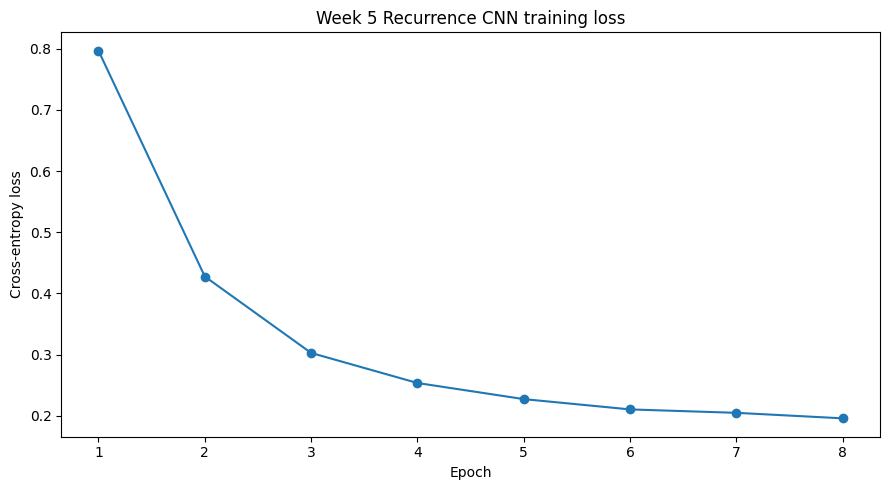

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_training_loss.png


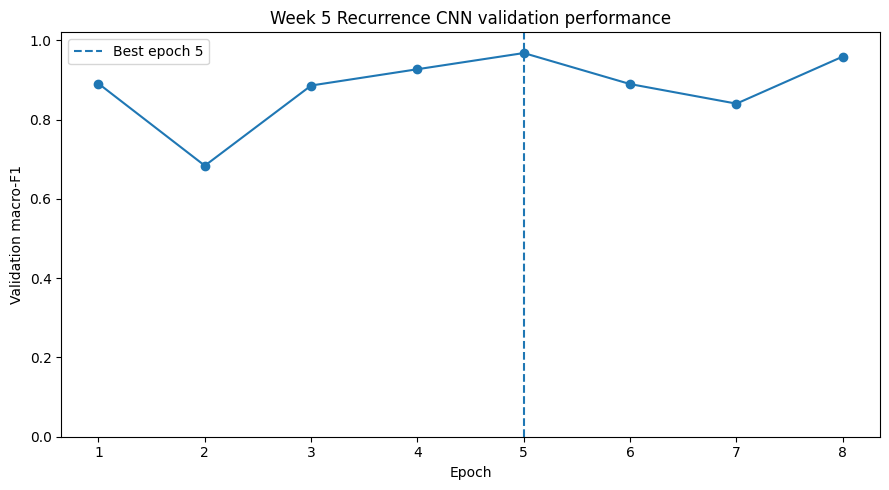

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_validation_macro_f1.png


In [34]:
# 16. Save training-history figures

plt.figure(figsize=(9, 5))

plt.plot(
    cnn_history["Epoch"],
    cnn_history[
        "Training_Loss"
    ],
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel(
    "Cross-entropy loss"
)
plt.title(
    "Week 5 Recurrence CNN training loss"
)

save_current_figure(
    "week05_cnn_training_loss.png"
)


plt.figure(figsize=(9, 5))

plt.plot(
    cnn_history["Epoch"],
    cnn_history[
        "Validation_Macro_F1"
    ],
    marker="o",
)

if best_epoch is not None:
    plt.axvline(
        best_epoch,
        linestyle="--",
        label=(
            f"Best epoch "
            f"{best_epoch}"
        ),
    )

plt.ylim(0, 1.02)
plt.xlabel("Epoch")
plt.ylabel(
    "Validation macro-F1"
)
plt.title(
    "Week 5 Recurrence CNN validation performance"
)

if best_epoch is not None:
    plt.legend()

save_current_figure(
    "week05_cnn_validation_macro_f1.png"
)

In [35]:
# 17. Save the selected CNN checkpoint

cnn_path = (
    MODEL_DIR
    / "week05_recurrence_cnn.pt"
)

torch.save({
    "state_dict":
        cnn.state_dict(),
    "class_names":
        CLASS_NAMES,
    "window_size":
        WINDOW_SIZE,
    "sequence_features": [
        "can_id_norm",
        "dlc_norm",
        "data_0",
        "data_1",
        "data_2",
        "data_3",
        "data_4",
        "data_5",
        "data_6",
        "data_7",
        "iat_log_norm",
    ],
    "recurrence_gamma":
        RECURRENCE_GAMMA,
    "best_epoch":
        best_epoch,
    "best_validation_macro_f1":
        float(
            best_validation_macro_f1
        ),
}, cnn_path)

print(
    "Saved CNN:",
    cnn_path,
)

Saved CNN: /kaggle/working/autospectra_week05_outputs/models/week05_recurrence_cnn.pt


# Part D — Held-Out Test Evaluation

In [36]:
# 18. Evaluation utilities

def expected_calibration_error(
    y_true,
    probabilities,
    bins=10,
):
    predictions = (
        probabilities.argmax(
            axis=1
        )
    )

    confidences = (
        probabilities.max(
            axis=1
        )
    )

    correctness = (
        predictions
        == y_true
    )

    edges = np.linspace(
        0,
        1,
        bins + 1,
    )

    ece = 0.0

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (
                    confidences
                    >= lower
                )
                & (
                    confidences
                    <= upper
                )
            )
        else:
            mask = (
                (
                    confidences
                    >= lower
                )
                & (
                    confidences
                    < upper
                )
            )

        if mask.any():
            bin_accuracy = (
                correctness[
                    mask
                ].mean()
            )

            bin_confidence = (
                confidences[
                    mask
                ].mean()
            )

            ece += (
                mask.mean()
                * abs(
                    bin_accuracy
                    - bin_confidence
                )
            )

    return float(ece)


def calculate_metrics(
    y_true,
    probabilities,
    inference_seconds,
):
    predictions = (
        probabilities.argmax(
            axis=1
        )
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            labels=np.arange(
                len(CLASS_NAMES)
            ),
            average="macro",
            zero_division=0,
        )
    )

    binary_true = (
        y_true
        != CLASS_TO_INDEX[
            "Normal"
        ]
    ).astype(int)

    binary_prediction = (
        predictions
        != CLASS_TO_INDEX[
            "Normal"
        ]
    ).astype(int)

    tn, fp, fn, tp = (
        confusion_matrix(
            binary_true,
            binary_prediction,
            labels=[0, 1],
        ).ravel()
    )

    y_binary = label_binarize(
        y_true,
        classes=np.arange(
            len(CLASS_NAMES)
        ),
    )

    try:
        macro_roc_auc = (
            roc_auc_score(
                y_true,
                probabilities,
                multi_class="ovr",
                average="macro",
            )
        )
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_pr_auc = (
            average_precision_score(
                y_binary,
                probabilities,
                average="macro",
            )
        )
    except ValueError:
        macro_pr_auc = np.nan

    model_size_mb = (
        cnn_path.stat().st_size
        / (1024 ** 2)
    )

    metrics = {
        "Model":
            "Recurrence CNN",
        "Accuracy":
            accuracy_score(
                y_true,
                predictions,
            ),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions,
            ),
        "Macro_Precision":
            macro_precision,
        "Macro_Recall":
            macro_recall,
        "Macro_F1":
            macro_f1,
        "Weighted_F1":
            f1_score(
                y_true,
                predictions,
                average="weighted",
                zero_division=0,
            ),
        "MCC":
            matthews_corrcoef(
                y_true,
                predictions,
            ),
        "Macro_ROC_AUC_OVR":
            macro_roc_auc,
        "Macro_PR_AUC":
            macro_pr_auc,
        "Attack_FPR":
            fp
            / max(
                fp + tn,
                1,
            ),
        "Attack_FNR":
            fn
            / max(
                fn + tp,
                1,
            ),
        "ECE_10_bins":
            expected_calibration_error(
                y_true,
                probabilities,
                bins=10,
            ),
        "Log_Loss":
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
            ),
        "Training_Seconds":
            cnn_training_seconds,
        "Inference_ms_per_window":
            inference_seconds
            * 1000
            / len(y_true),
        "Throughput_windows_per_second":
            len(y_true)
            / max(
                inference_seconds,
                1e-9,
            ),
        "Model_Size_MB":
            model_size_mb,
        "Best_Epoch":
            best_epoch,
        "Best_Validation_Macro_F1":
            best_validation_macro_f1,
    }

    return (
        metrics,
        predictions,
    )

In [37]:
# 19. Predict the held-out test split

(
    validation_probabilities,
    validation_labels,
) = probabilities_from_cnn(
    cnn,
    cnn_validation_loader,
)

assert np.array_equal(
    validation_labels,
    y_validation,
)

inference_start = (
    time.perf_counter()
)

(
    test_probabilities,
    test_labels,
) = probabilities_from_cnn(
    cnn,
    cnn_test_loader,
)

cnn_inference_seconds = (
    time.perf_counter()
    - inference_start
)

assert np.array_equal(
    test_labels,
    y_test,
)

(
    cnn_metrics,
    test_predictions,
) = calculate_metrics(
    y_test,
    test_probabilities,
    cnn_inference_seconds,
)

metrics_df = pd.DataFrame(
    [cnn_metrics]
)

display(
    metrics_df.T.rename(
        columns={0: "Value"}
    )
)

metrics_df.to_csv(
    REPORT_DIR
    / "week05_cnn_metrics.csv",
    index=False,
)

report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(
            len(CLASS_NAMES)
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df)

report_df.to_csv(
    REPORT_DIR
    / "week05_cnn_classification_report.csv"
)

,Value
Model,Recurrence CNN
Accuracy,0.97025
Balanced_Accuracy,0.97025
Macro_Precision,0.971043
Macro_Recall,0.97025
Macro_F1,0.970185
Weighted_F1,0.970185
MCC,0.963042
Macro_ROC_AUC_OVR,0.997373
Macro_PR_AUC,0.992821


,precision,recall,f1-score,support
Normal,0.941107,0.99875,0.969072,800.00000
DoS,1.000000,0.97500,0.987342,800.00000
Fuzzy,0.985037,0.98750,0.986267,800.00000
Gear,0.982597,0.91750,0.948933,800.00000
RPM,0.946472,0.97250,0.959309,800.00000
accuracy,0.970250,0.97025,0.970250,0.97025
macro avg,0.971043,0.97025,0.970185,4000.00000
weighted avg,0.971043,0.97025,0.970185,4000.00000


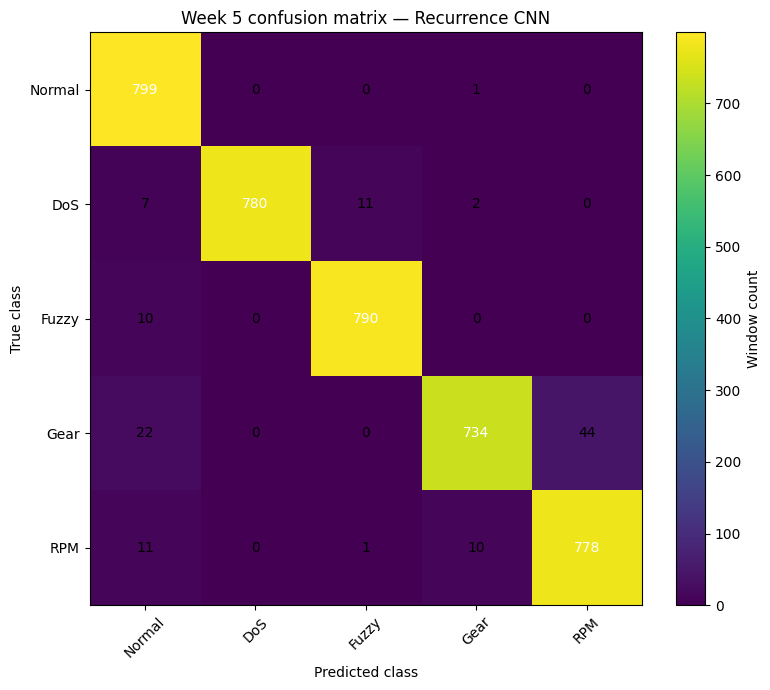

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_confusion_matrix.png


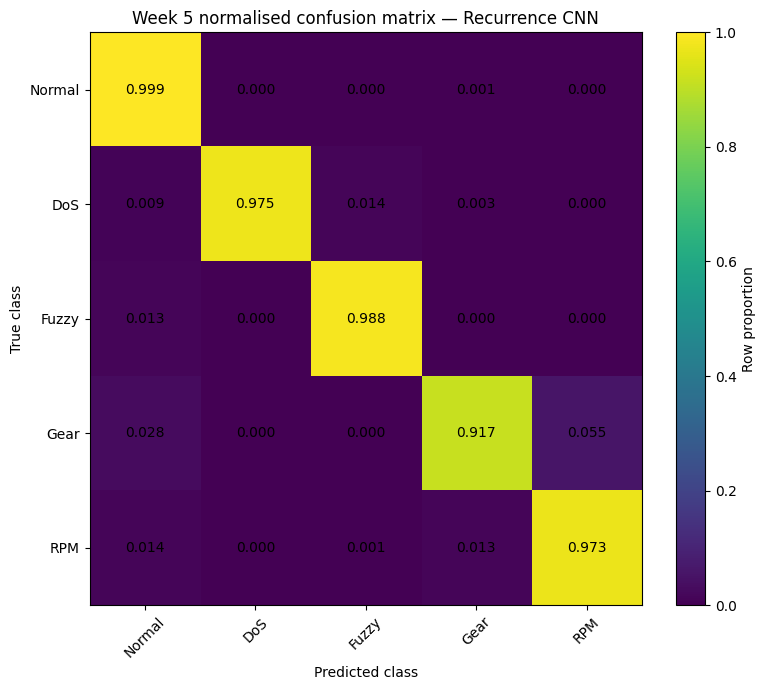

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_confusion_matrix_normalised.png


In [38]:
# 20. Save confusion matrix and normalised confusion matrix

matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=np.arange(
        len(CLASS_NAMES)
    ),
)

plt.figure(figsize=(8, 7))
image = plt.imshow(
    matrix,
    aspect="auto",
)
plt.colorbar(
    image,
    label="Window count",
)
plt.xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
)
plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
)

threshold = (
    matrix.max() / 2
)

for row in range(
    matrix.shape[0]
):
    for column in range(
        matrix.shape[1]
    ):
        plt.text(
            column,
            row,
            f"{matrix[row, column]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if matrix[
                    row,
                    column
                ] > threshold
                else "black"
            ),
        )

plt.title(
    "Week 5 confusion matrix — Recurrence CNN"
)
plt.xlabel(
    "Predicted class"
)
plt.ylabel(
    "True class"
)

save_current_figure(
    "week05_cnn_confusion_matrix.png"
)


row_totals = (
    matrix.sum(
        axis=1,
        keepdims=True,
    )
)

normalised_matrix = (
    matrix
    / np.maximum(
        row_totals,
        1,
    )
)

plt.figure(figsize=(8, 7))
image = plt.imshow(
    normalised_matrix,
    vmin=0,
    vmax=1,
    aspect="auto",
)
plt.colorbar(
    image,
    label="Row proportion",
)
plt.xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
)
plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
)

for row in range(
    normalised_matrix.shape[0]
):
    for column in range(
        normalised_matrix.shape[1]
    ):
        plt.text(
            column,
            row,
            f"{normalised_matrix[row, column]:.3f}",
            ha="center",
            va="center",
        )

plt.title(
    "Week 5 normalised confusion matrix — Recurrence CNN"
)
plt.xlabel(
    "Predicted class"
)
plt.ylabel(
    "True class"
)

save_current_figure(
    "week05_cnn_confusion_matrix_normalised.png"
)

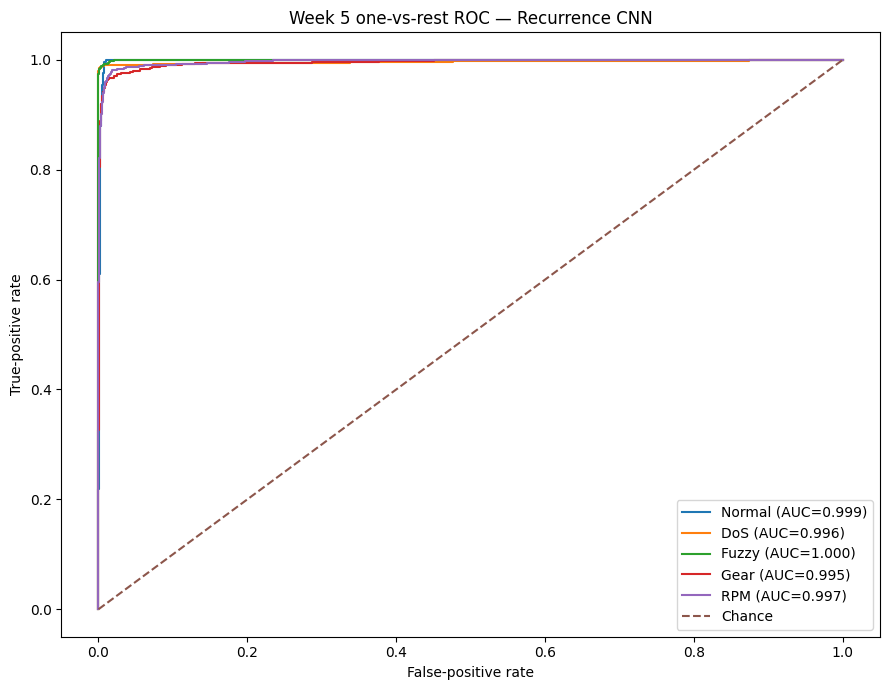

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_roc_curves.png


In [39]:
# 21. Save ROC curves

y_binary = label_binarize(
    y_test,
    classes=np.arange(
        len(CLASS_NAMES)
    ),
)

plt.figure(figsize=(9, 7))

for (
    class_index,
    class_name,
) in enumerate(CLASS_NAMES):

    (
        false_positive_rate,
        true_positive_rate,
        _,
    ) = roc_curve(
        y_binary[
            :, class_index
        ],
        test_probabilities[
            :, class_index
        ],
    )

    curve_auc = auc(
        false_positive_rate,
        true_positive_rate,
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{class_name} "
            f"(AUC={curve_auc:.3f})"
        ),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)

plt.xlabel(
    "False-positive rate"
)
plt.ylabel(
    "True-positive rate"
)
plt.title(
    "Week 5 one-vs-rest ROC — Recurrence CNN"
)
plt.legend()

save_current_figure(
    "week05_cnn_roc_curves.png"
)

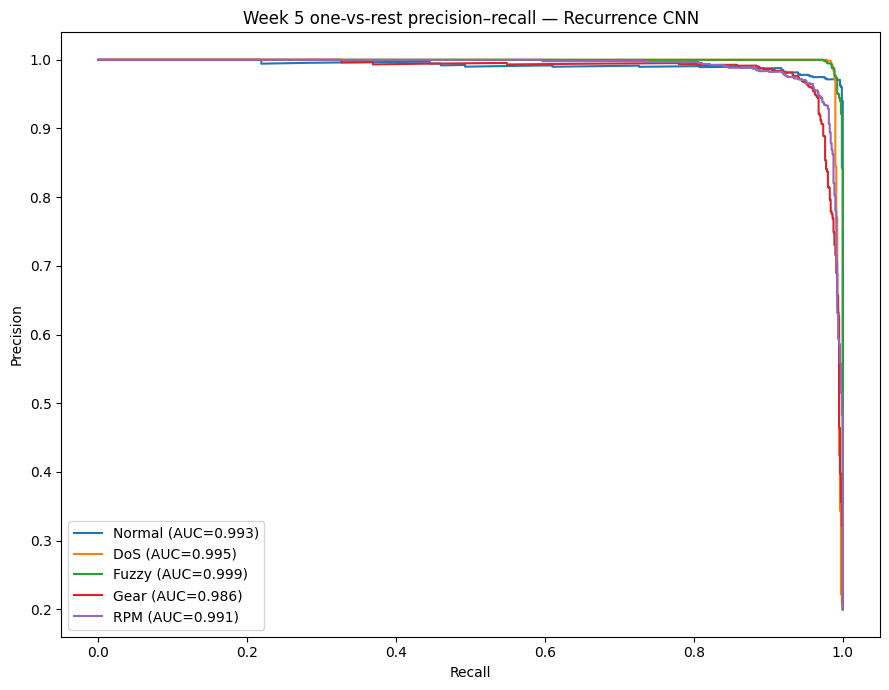

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_precision_recall_curves.png


In [40]:
# 22. Save precision–recall curves

plt.figure(figsize=(9, 7))

for (
    class_index,
    class_name,
) in enumerate(CLASS_NAMES):

    precision, recall, _ = (
        precision_recall_curve(
            y_binary[
                :, class_index
            ],
            test_probabilities[
                :, class_index
            ],
        )
    )

    curve_auc = auc(
        recall,
        precision,
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{class_name} "
            f"(AUC={curve_auc:.3f})"
        ),
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Week 5 one-vs-rest precision–recall — Recurrence CNN"
)
plt.legend()

save_current_figure(
    "week05_cnn_precision_recall_curves.png"
)

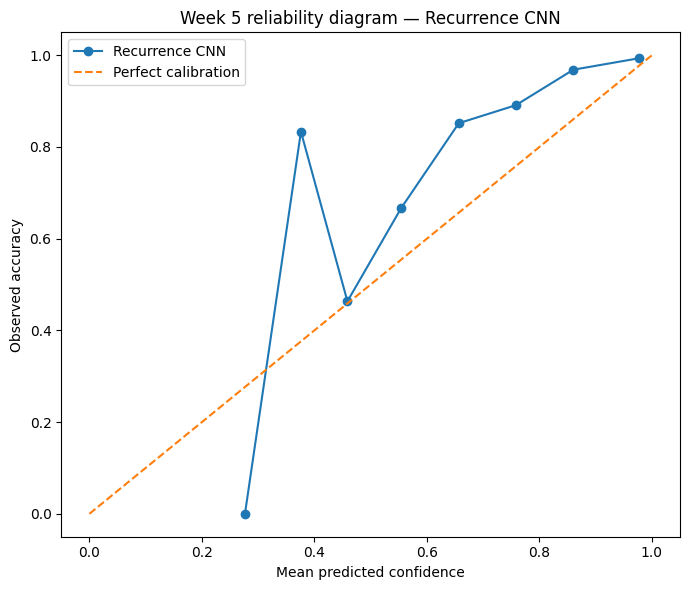

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_reliability.png


In [41]:
# 23. Save reliability diagram

confidence = (
    test_probabilities.max(
        axis=1
    )
)

correctness = (
    test_predictions
    == y_test
).astype(float)

edges = np.linspace(
    0,
    1,
    11,
)

mean_confidence = []
empirical_accuracy = []

for lower, upper in zip(
    edges[:-1],
    edges[1:],
):
    if upper == 1.0:
        mask = (
            (confidence >= lower)
            & (confidence <= upper)
        )
    else:
        mask = (
            (confidence >= lower)
            & (confidence < upper)
        )

    if mask.any():
        mean_confidence.append(
            confidence[
                mask
            ].mean()
        )
        empirical_accuracy.append(
            correctness[
                mask
            ].mean()
        )

plt.figure(figsize=(7, 6))

plt.plot(
    mean_confidence,
    empirical_accuracy,
    marker="o",
    label="Recurrence CNN",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel(
    "Mean predicted confidence"
)
plt.ylabel(
    "Observed accuracy"
)
plt.title(
    "Week 5 reliability diagram — Recurrence CNN"
)
plt.legend()

save_current_figure(
    "week05_cnn_reliability.png"
)

,Class,Precision,Recall,F1,Support
0,Normal,0.941107,0.99875,0.969072,800
1,DoS,1.000000,0.97500,0.987342,800
2,Fuzzy,0.985037,0.98750,0.986267,800
3,Gear,0.982597,0.91750,0.948933,800
4,RPM,0.946472,0.97250,0.959309,800


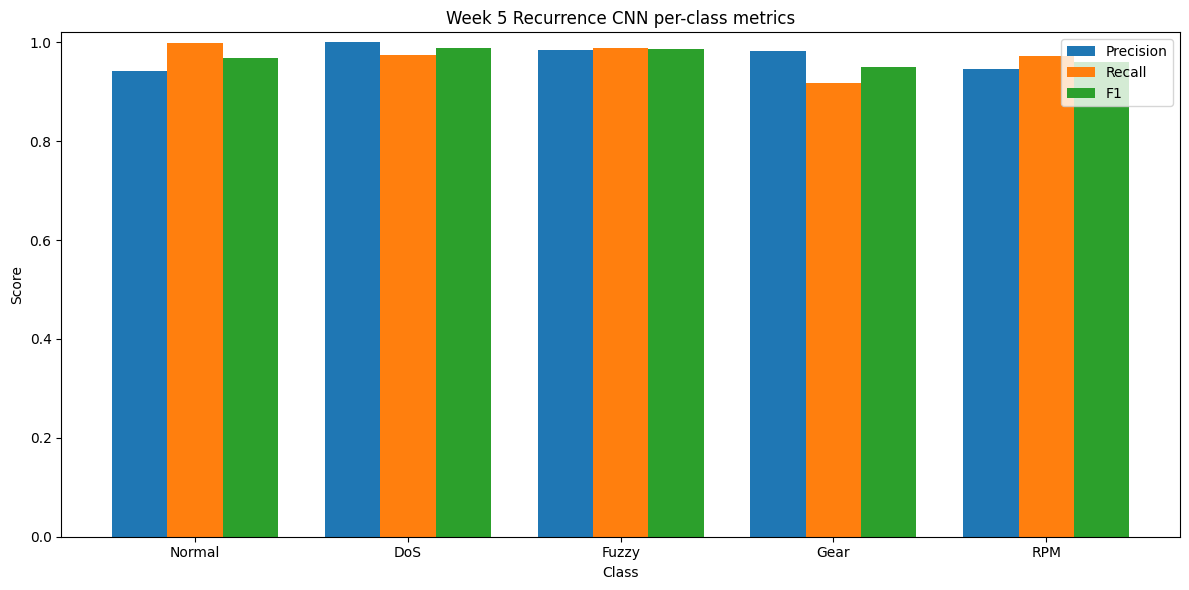

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_per_class_metrics.png


In [42]:
# 24. Save per-class precision, recall and F1

(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    per_class_support,
) = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        labels=np.arange(
            len(CLASS_NAMES)
        ),
        zero_division=0,
    )
)

per_class_df = pd.DataFrame({
    "Class":
        CLASS_NAMES,
    "Precision":
        per_class_precision,
    "Recall":
        per_class_recall,
    "F1":
        per_class_f1,
    "Support":
        per_class_support.astype(
            int
        ),
})

display(per_class_df)

per_class_df.to_csv(
    REPORT_DIR
    / "week05_cnn_per_class_metrics.csv",
    index=False,
)

x = np.arange(
    len(CLASS_NAMES)
)

width = 0.26

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x - width,
    per_class_precision,
    width=width,
    label="Precision",
)

plt.bar(
    x,
    per_class_recall,
    width=width,
    label="Recall",
)

plt.bar(
    x + width,
    per_class_f1,
    width=width,
    label="F1",
)

plt.xticks(
    x,
    CLASS_NAMES,
)
plt.ylim(
    0,
    1.02,
)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title(
    "Week 5 Recurrence CNN per-class metrics"
)
plt.legend()

save_current_figure(
    "week05_cnn_per_class_metrics.png"
)

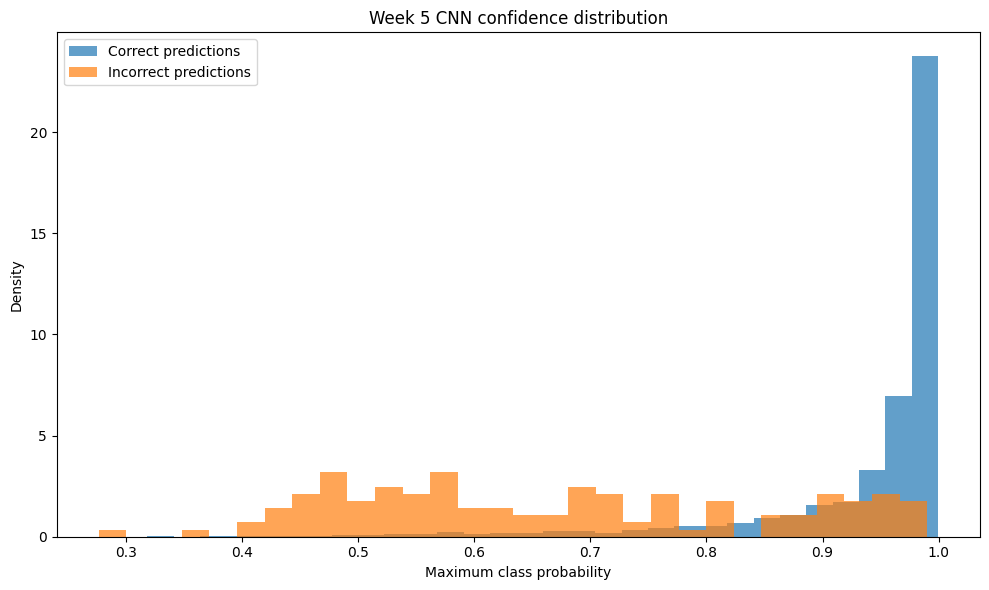

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_confidence_distribution.png


,Class,Test_Windows,Errors,Error_Rate
0,Normal,800,1,0.00125
1,DoS,800,20,0.02500
2,Fuzzy,800,10,0.01250
3,Gear,800,66,0.08250
4,RPM,800,22,0.02750


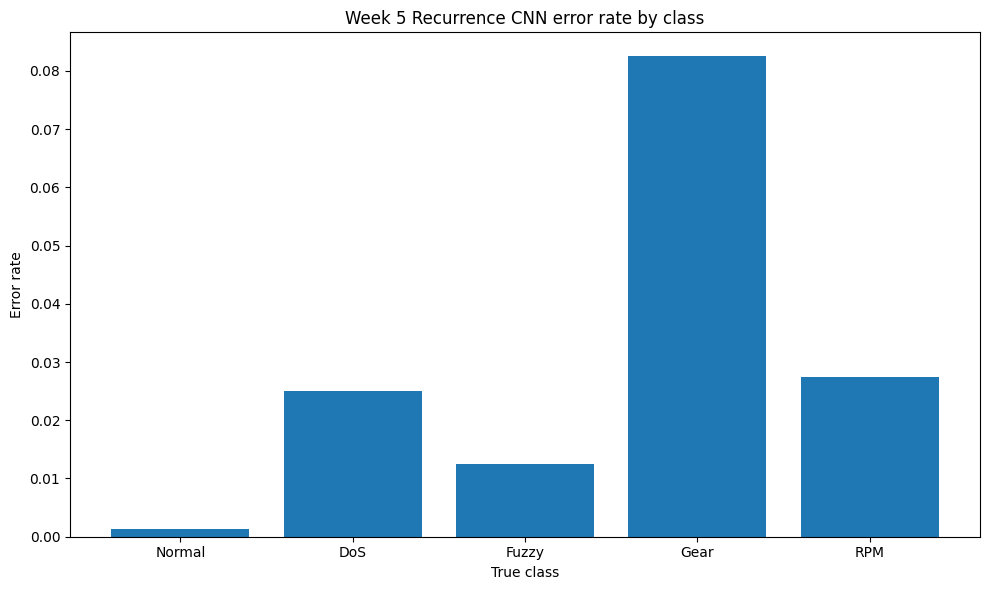

Saved image: /kaggle/working/autospectra_week05_outputs/plots/week05_cnn_error_rate_by_class.png


In [43]:
# 25. Save confidence distribution and error-confidence analysis

correct_mask = (
    test_predictions
    == y_test
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    confidence[
        correct_mask
    ],
    bins=30,
    alpha=0.7,
    density=True,
    label="Correct predictions",
)

if (
    (~correct_mask).any()
):
    plt.hist(
        confidence[
            ~correct_mask
        ],
        bins=30,
        alpha=0.7,
        density=True,
        label="Incorrect predictions",
    )

plt.xlabel(
    "Maximum class probability"
)
plt.ylabel("Density")
plt.title(
    "Week 5 CNN confidence distribution"
)
plt.legend()

save_current_figure(
    "week05_cnn_confidence_distribution.png"
)


error_rows = []

for true_index in range(
    len(CLASS_NAMES)
):
    class_mask = (
        y_test
        == true_index
    )

    error_rows.append({
        "Class":
            CLASS_NAMES[
                true_index
            ],
        "Test_Windows":
            int(
                class_mask.sum()
            ),
        "Errors":
            int(
                (
                    class_mask
                    & (~correct_mask)
                ).sum()
            ),
        "Error_Rate":
            float(
                (
                    class_mask
                    & (~correct_mask)
                ).sum()
                / max(
                    class_mask.sum(),
                    1,
                )
            ),
    })

error_df = pd.DataFrame(
    error_rows
)

display(error_df)

error_df.to_csv(
    REPORT_DIR
    / "week05_cnn_error_by_class.csv",
    index=False,
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    error_df["Class"],
    error_df["Error_Rate"],
)

plt.xlabel("True class")
plt.ylabel("Error rate")
plt.title(
    "Week 5 Recurrence CNN error rate by class"
)

save_current_figure(
    "week05_cnn_error_rate_by_class.png"
)

# Part E — Week 5 Evidence Export

In [44]:
# 26. Export Week 5 summary and downloadable ZIP files

week5_summary = {
    "project":
        "AutoSPECTRA",
    "week":
        5,
    "scope":
        "Recurrence-image encoding and CNN classification",
    "classes":
        CLASS_NAMES,
    "window_size":
        WINDOW_SIZE,
    "stride":
        STRIDE,
    "split_strategy":
        SPLIT_STRATEGY,
    "sequence_shape":
        [WINDOW_SIZE, 11],
    "recurrence_shape":
        [WINDOW_SIZE, WINDOW_SIZE],
    "recurrence_gamma":
        RECURRENCE_GAMMA,
    "cnn_total_parameters":
        int(total_parameters),
    "cnn_trainable_parameters":
        int(
            trainable_parameters
        ),
    "best_epoch":
        (
            int(best_epoch)
            if best_epoch
            is not None
            else None
        ),
    "best_validation_macro_f1":
        float(
            best_validation_macro_f1
        ),
    "test_metrics":
        {
            key:
                (
                    float(value)
                    if isinstance(
                        value,
                        (
                            np.floating,
                            float,
                            int,
                        ),
                    )
                    else value
                )
            for key, value
            in cnn_metrics.items()
        },
    "lstm_trained":
        False,
    "autoencoder_trained":
        False,
    "fusion_performed":
        False,
    "next_week":
        "Bidirectional LSTM and normal-only LSTM autoencoder",
}

summary_path = (
    REPORT_DIR
    / "week05_summary.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        week5_summary,
        handle,
        indent=2,
    )

image_files = sorted(
    PLOT_DIR.glob(
        "*.png"
    )
)

image_manifest = pd.DataFrame([
    {
        "Image":
            path.name,
        "Size_KB":
            round(
                path.stat().st_size
                / 1024,
                2,
            ),
        "Kaggle_Path":
            str(path),
    }
    for path in image_files
])

display(image_manifest)

image_manifest.to_csv(
    REPORT_DIR
    / "week05_image_manifest.csv",
    index=False,
)

images_zip = Path(
    "/kaggle/working/AutoSPECTRA_Week05_Images.zip"
)

with zipfile.ZipFile(
    images_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for path in image_files:
        archive.write(
            path,
            arcname=path.name,
        )

evidence_zip = Path(
    "/kaggle/working/AutoSPECTRA_Week05_Evidence.zip"
)

with zipfile.ZipFile(
    evidence_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:

    for directory in [
        REPORT_DIR,
        PLOT_DIR,
    ]:
        for path in (
            directory.rglob(
                "*"
            )
        ):
            if path.is_file():
                archive.write(
                    path,
                    arcname=
                        path.relative_to(
                            OUTPUT_DIR
                        ),
                )

print("=" * 90)
print(
    "AUTOSPECTRA WEEK 5 COMPLETE"
)
print("=" * 90)
print(
    "Best validation macro-F1:",
    best_validation_macro_f1,
)
print(
    "Test macro-F1:",
    cnn_metrics[
        "Macro_F1"
    ],
)
print(
    "Images saved:",
    len(image_files),
)
print(
    "Images ZIP:",
    images_zip,
)
print(
    "Evidence ZIP:",
    evidence_zip,
)

print(
    "\nSaved Week 5 images:"
)

for path in image_files:
    print(
        " -",
        path.name,
    )

,Image,Size_KB,Kaggle_Path
0,week05_cnn_confidence_distribution.png,54.98,/kaggle/working/autospectra_week05_outputs/plo...
1,week05_cnn_confusion_matrix.png,93.57,/kaggle/working/autospectra_week05_outputs/plo...
2,week05_cnn_confusion_matrix_normalised.png,110.07,/kaggle/working/autospectra_week05_outputs/plo...
3,week05_cnn_error_rate_by_class.png,55.67,/kaggle/working/autospectra_week05_outputs/plo...
4,week05_cnn_parameter_breakdown.png,117.74,/kaggle/working/autospectra_week05_outputs/plo...
5,week05_cnn_per_class_metrics.png,53.38,/kaggle/working/autospectra_week05_outputs/plo...
6,week05_cnn_precision_recall_curves.png,95.05,/kaggle/working/autospectra_week05_outputs/plo...
7,week05_cnn_reliability.png,102.85,/kaggle/working/autospectra_week05_outputs/plo...
8,week05_cnn_roc_curves.png,116.62,/kaggle/working/autospectra_week05_outputs/plo...
9,week05_cnn_training_loss.png,67.83,/kaggle/working/autospectra_week05_outputs/plo...


AUTOSPECTRA WEEK 5 COMPLETE
Best validation macro-F1: 0.9677906294435432
Test macro-F1: 0.9701848034231497
Images saved: 14
Images ZIP: /kaggle/working/AutoSPECTRA_Week05_Images.zip
Evidence ZIP: /kaggle/working/AutoSPECTRA_Week05_Evidence.zip

Saved Week 5 images:
 - week05_cnn_confidence_distribution.png
 - week05_cnn_confusion_matrix.png
 - week05_cnn_confusion_matrix_normalised.png
 - week05_cnn_error_rate_by_class.png
 - week05_cnn_parameter_breakdown.png
 - week05_cnn_per_class_metrics.png
 - week05_cnn_precision_recall_curves.png
 - week05_cnn_reliability.png
 - week05_cnn_roc_curves.png
 - week05_cnn_training_loss.png
 - week05_cnn_validation_macro_f1.png
 - week05_recurrence_examples.png
 - week05_recurrence_signals.png
 - week05_recurrence_similarity_by_class.png


# Week 5 Completion Summary

## Completed

- Reused the protected source-aware chronological split.
- Converted `64 × 11` CAN sequences into `64 × 64` recurrence-style images.
- Inspected recurrence patterns across all five classes.
- Implemented the compact three-block Recurrence CNN.
- Used weighted cross-entropy with label smoothing.
- Used AdamW, gradient clipping and validation macro-F1 early stopping.
- Saved the best validation checkpoint.
- Evaluated only the selected checkpoint on the held-out test set.
- Saved confusion, ROC, PR and reliability plots.
- Saved training-history and CNN parameter plots.
- Saved per-class and error-analysis plots.
- Created a PNG-only image ZIP for GitHub.
- Created a Week 5 evidence ZIP containing figures and reports.

## Critical Limitation

The recurrence transformation compresses eight payload bytes into their mean before pairwise distance is calculated. This makes the image representation computationally compact, but some payload detail is lost. A lower CNN score than the Week 4 tree baselines would therefore be an informative result rather than a failure.

Strong within-dataset performance must also be interpreted cautiously because CAN IDs can act as vehicle-specific shortcuts and the HCRL benchmark represents one vehicle platform.

## Kaggle Downloads

```text
/kaggle/working/AutoSPECTRA_Week05_Images.zip
/kaggle/working/AutoSPECTRA_Week05_Evidence.zip
```

## GitHub Notebook Path

```text
notebooks/week05/autospectra_week05_recurrence_cnn.ipynb
```

## Recommended Notebook Commit

```text
Notebook: add Week 5 recurrence-image CNN training and evaluation
```

## Week 6 Handover

Week 6 will train:

- Bidirectional LSTM classifier;
- normal-only LSTM autoencoder.

Both models will use the same protected sequence arrays.